# ISAC Plots
Note: This notebook is pretty miscellaneous, although it does include some plotly express code not found elsewhere. For the main plots, check out the Data and Visualization notebooks in the PACSUN folder.

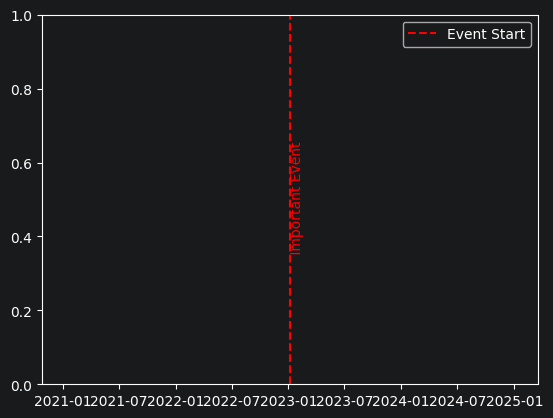

In [1]:
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Prepare your date
event_date = datetime(2023, 1, 5)

# 2. Add the vertical line
plt.axvline(x=event_date, color='r', linestyle='--', label='Event Start')

# 3. Add a text label (optional)
# x = event_date, y = height on plot
plt.text(event_date, 0.5, ' Important Event', color='red', rotation=90, verticalalignment='center')

plt.legend()
plt.show()

## Data Plotting - Single Unit

In [181]:
# import pandas as pd
# import plotly.express as px
# filename = "ISAC3_mid_113"
# with open(filename+".TXT", 'r') as file:
#     lines = file.readlines()
#     if len(lines) > 1:
#         # Get the second line and strip the trailing newline character
#         SN = lines[1].strip('\n')
#         print(SN)
#     else:
#         print("File has fewer than two lines.")


# df = pd.read_csv(filename+".TXT", skiprows = 4)
# df.columns = ['unixTime','background','ambient', 'backscatter', 'pressure','waterTemp','battery']
# df['Datetime'] = pd.to_datetime(df['unixTime'], unit='s') #
# df = df.sort_values(by="unixTime")

# # Get S/N....
# with open(filename+".TXT", 'r') as file:
#     lines = file.readlines()
#     if len(lines) > 1:
#         # Get the second line and strip the trailing newline character
#         SN = lines[1].strip('\n')
#         print(SN)
#     else:
#         print("File has fewer than two lines.")

# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # Create figure with secondary y-axis
# fig = make_subplots(specs=[[{"secondary_y": True}]])

# # Add traces
# fig.add_trace(
#     go.Scatter(x=df["Datetime"], y=df["ambient"], name="Ambient Light"),
#     secondary_y=False,
# )

# fig.add_trace(
#     go.Scatter(x=df["Datetime"], y=df["backscatter"], name="Backscatter"),
#     secondary_y=True,
# )

# # Add figure title
# fig.update_layout(
#     title_text=SN
# )

# # Set x-axis title
# fig.update_xaxes(title_text="Time")

# # Set y-axes titles
# fig.update_yaxes(title_text="Ambient", secondary_y=False)
# fig.update_yaxes(title_text="Backscatter", secondary_y=True)

# fig.show()
# fig.write_html(filename+'.html')

In [223]:
# Unify our tables....
dfs = []

for filename in ["ISAC2_mid_123"]:
    df = pd.read_csv(filename+".TXT", skiprows = 4)
    df.columns = ['unixTime','background','ambient', 'backscatter', 'pressure','waterTemp','battery']
    df['backscatter_median'] = df['backscatter'].rolling(window=20, center=True).median()
    df['ambient_median'] = df['ambient'].rolling(window=11, center=True).median()
    df['Datetime'] = pd.to_datetime(df['unixTime'], unit='s').dt.tz_localize('UTC').dt.tz_convert('Pacific/Tongatapu') #
    df = df.sort_values(by="Datetime")

    # Get S/N....
    with open(filename+".TXT", 'r') as file:
        lines = file.readlines()
        if len(lines) > 1:
            # Get the second line and strip the trailing newline character
            SN = lines[1].strip('\n')
            print(SN)
        else:
            print("File has fewer than two lines.")
    

    suffix = "_" +SN[11:15]
    df.columns = [
        f"{col}{suffix}" if col != 'Datetime' else col 
        for col in df.columns
    ]
    dfs.append(df)

# Concatenate all the things:
df = pd.concat(dfs, ignore_index=True)

# Localize datetime to Tonga, assuming computer RTC is in Pacific Time:
# df['Datetime'] = df['Datetime'].dt.tz_localize('Pacific/Tongatapu')

# Calculate solar zenith angle:
times = df['Datetime']
solpos = get_solarposition(times, -21, -175) # lat, lon
df['zenith'] = solpos['zenith'].values
df['elevation'] = solpos['elevation'].values
df['azimuth'] = solpos['azimuth'].values
# Filter to time range of experiment:
# df = df[df['Datetime'].between('2026-03-21', '2026-03-23')]
df = df.sort_values('Datetime') # sort to avoid plotting errors

# Sanity check: This should be noonish.
peak_sun = df.loc[df['zenith'].idxmin()]
print(f"Sun is highest at: {peak_sun['Datetime']}")

OpenOBS SN:123
Sun is highest at: 2026-03-21 12:47:12+13:00


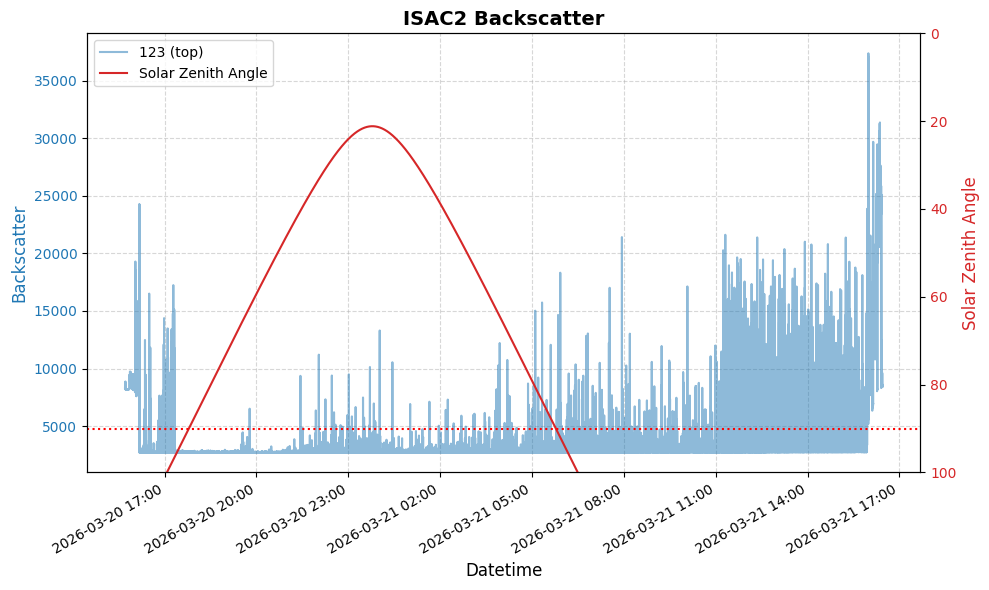

In [220]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df = df.sort_values('Datetime')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['backscatter_median_123'], label='123 (top)', color='tab:blue', alpha = 0.5)
# line2, = ax1.plot(df['Datetime'], df['backscatter_median_117'], label='117 (mid)', color='tab:green', alpha = 0.5)
# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# Formatting the X-axis (Dates)
fig.autofmt_xdate()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('ISAC2 Backscatter', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## ISAC3 Plots

In [282]:
# Unify our tables....
dfs = []

for filename in ["ISAC3_mid_113", "ISAC3_mid_117", "ISAC3_top_123"]:
    df = pd.read_csv(filename+".TXT", skiprows = 4)
    df.columns = ['unixTime','background','ambient', 'backscatter', 'pressure','waterTemp','battery']
    df = df.groupby('unixTime', as_index=False).mean() 
    df['Datetime'] = pd.to_datetime(df['unixTime'], unit='s').dt.tz_localize('UTC').dt.tz_convert('Pacific/Tongatapu') #
    # df = df.reset_index().groupby('unixTime').mean() # Multiple datapoints for 1 second? let's average those out.
    df['backscatter_filtered'] = df['backscatter'].rolling(window=20, center=True).median()
    df['ambient_filtered'] = df['ambient'].rolling(window=11, center=True).median()

    # df = df.sort_values(by="unixTime")

    # Get S/N....
    with open(filename+".TXT", 'r') as file:
        lines = file.readlines()
        if len(lines) > 1:
            # Get the second line and strip the trailing newline character
            SN = lines[1].strip('\n')
            print(SN)
        else:
            print("File has fewer than two lines.")
    

    suffix = "_" +SN[11:15]
    df.columns = [
        f"{col}{suffix}" if col != 'Datetime' else col 
        for col in df.columns
    ]
    dfs.append(df)

# Concatenate all the things:
df = pd.concat(dfs, ignore_index=True)

# Localize datetime to Tonga, assuming computer RTC is in Pacific Time:
# df['Datetime'] = df['Datetime'].dt.tz_localize('Pacific/Tongatapu')

# Calculate solar zenith angle:
times = df['Datetime']
solpos = get_solarposition(times, -21, -175) # lat, lon
df['zenith'] = solpos['zenith'].values
df['elevation'] = solpos['elevation'].values
df['azimuth'] = solpos['azimuth'].values
# Filter to time range of experiment:
# df = df[df['Datetime'].between('2026-03-21', '2026-03-23')]
df = df.sort_values('Datetime') # sort to avoid plotting errors

# Sanity check: This should be noonish.
peak_sun = df.loc[df['zenith'].idxmin()]
print(f"Sun is highest at: {peak_sun['Datetime']}")

OpenOBS SN:113
OpenOBS SN:117
OpenOBS SN:123
Sun is highest at: 2026-03-22 12:46:54+13:00


In [283]:
print(df.Datetime.min())
print(df.Datetime.max())

start = pd.Timestamp('2026-03-22 7:00:00').tz_localize('Pacific/Tongatapu')
end = pd.Timestamp('2026-03-23 7:00:00').tz_localize('Pacific/Tongatapu')

# Filter
df = df[df['Datetime'].between(start, end)]

print(df.Datetime.min())
print(df.Datetime.max())

2026-03-22 02:33:43+13:00
2026-03-24 00:54:56+13:00
2026-03-22 07:00:00+13:00
2026-03-23 07:00:00+13:00


In [254]:
# foo = df[df['Datetime'].between('2026-03-21 18:00:00', '2026-03-22 18:00:00')]
# foo

In [280]:
df.columns

Index(['unixTime_113', 'background_113', 'ambient_113', 'backscatter_113',
       'pressure_113', 'waterTemp_113', 'battery_113', 'Datetime',
       'backscatter_median_113', 'ambient_median_113', 'unixTime_117',
       'background_117', 'ambient_117', 'backscatter_117', 'pressure_117',
       'waterTemp_117', 'battery_117', 'backscatter_median_117',
       'ambient_median_117', 'unixTime_123', 'background_123', 'ambient_123',
       'backscatter_123', 'pressure_123', 'waterTemp_123', 'battery_123',
       'backscatter_median_123', 'ambient_median_123', 'zenith', 'elevation',
       'azimuth'],
      dtype='object')

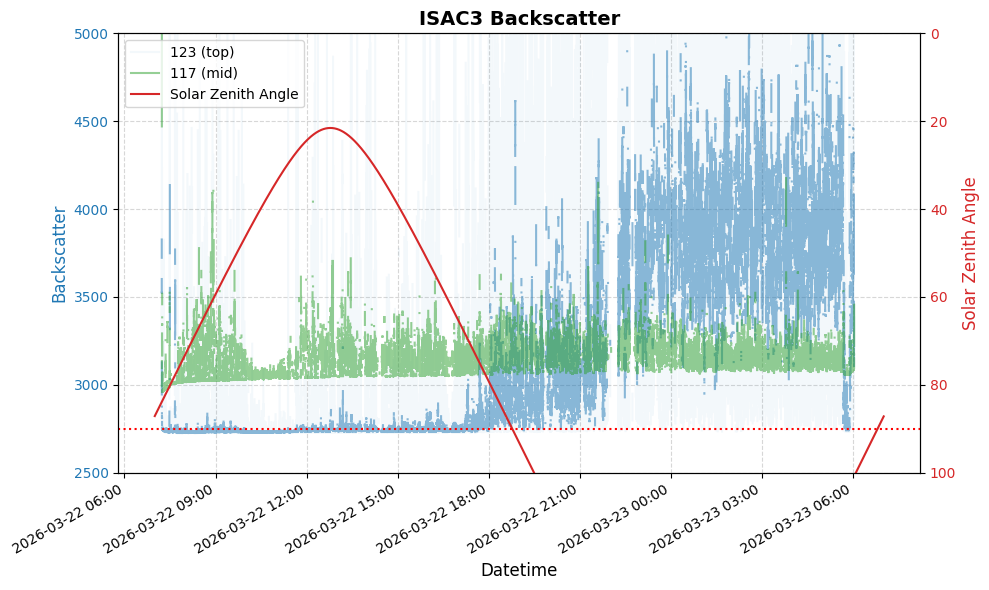

In [286]:
# # Define your window
# start = pd.Timestamp('2026-03-21 18:00:00').tz_localize('Pacific/Tongatapu')
# end = pd.Timestamp('2026-03-22 18:00:00').tz_localize('Pacific/Tongatapu')

# # Filter
# df = df[df['Datetime'].between(start, end)]


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# df = df.sort_values('Datetime')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'].dt.tz_localize(None), df['backscatter_123'], label='123 (top)', color='tab:blue', alpha = 0.05)
line1b  = ax1.plot(df['Datetime'].dt.tz_localize(None), df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)
line2, = ax1.plot(df['Datetime'].dt.tz_localize(None), df['backscatter_filtered_117'], label='117 (mid)', color='tab:green', alpha = 0.5)
# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'].dt.tz_localize(None), df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_ylim(2500, 5000)
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# Formatting the X-axis (Dates)
fig.autofmt_xdate()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

# Combine legends from both axes into one box
lines = [line1, line2, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('ISAC3 Backscatter', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

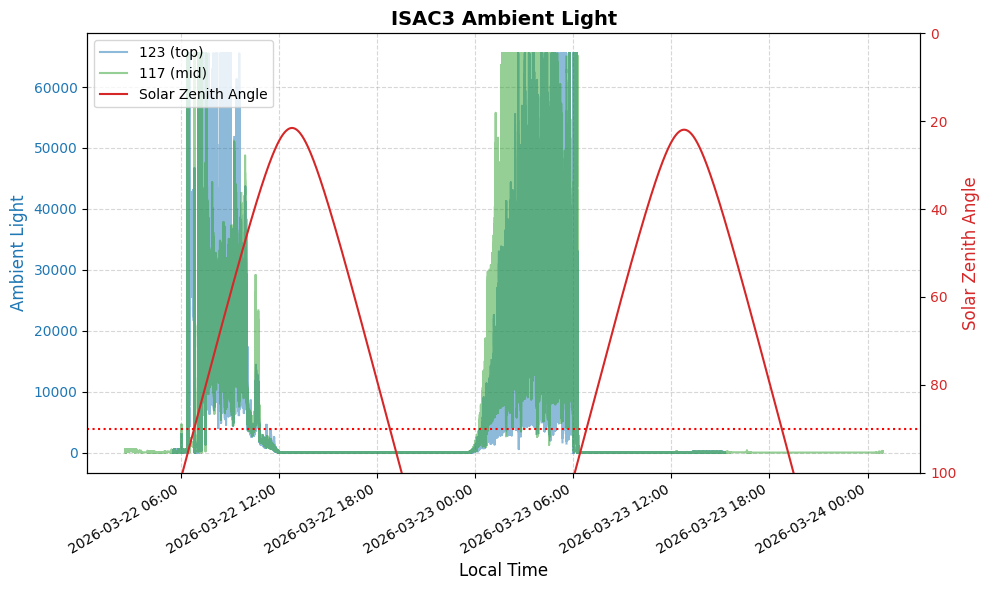

In [216]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz

# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['ambient_123'], label='123 (top)', color='tab:blue', alpha=0.5)
line2, = ax1.plot(df['Datetime'], df['ambient_117'], label='117 (mid)', color='tab:green', alpha = 0.5)
# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Local Time', fontsize=12)
ax1.set_ylabel('Ambient Light', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# Formatting the X-axis (Dates)
fig.autofmt_xdate()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=pytz.timezone('Pacific/Tongatapu')))

# Combine legends from both axes into one box
lines = [line1, line2, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('ISAC3 Ambient Light', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

/tmp/ipykernel_257/2160409376.py:25: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



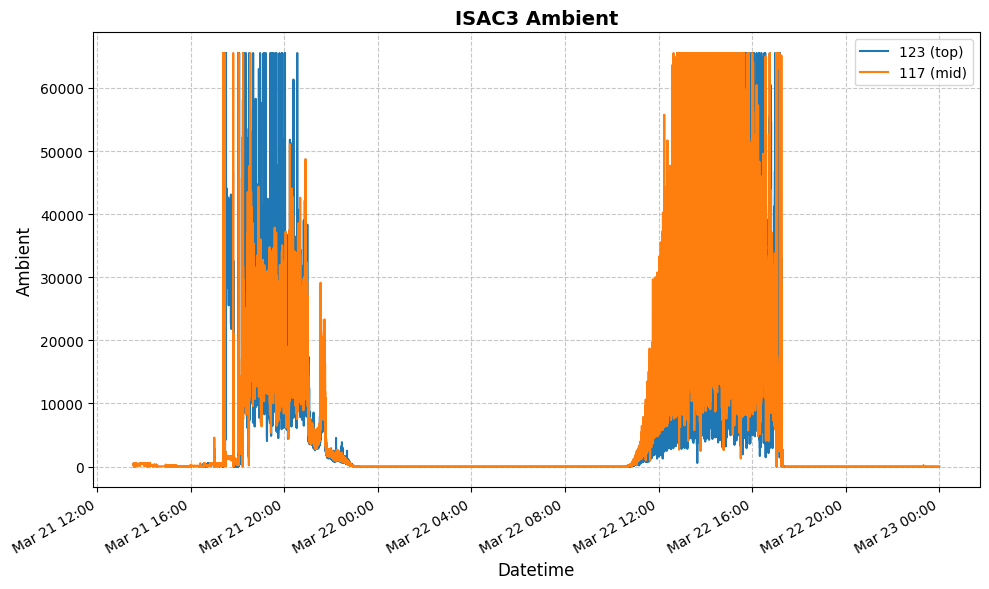

In [113]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# # Create the plot
# plt.figure(figsize=(10, 6)) # Optional: makes the plot wider for better date visibility

# plt.plot(df['Datetime'], df['ambient_123'], label='123 (top)')
# plt.plot(df['Datetime'], df['ambient_117'], label='117 (mid)')
# # plt.plot(df['Datetime'], df['backscatter_113'], label='113 (mid)')

# # Add Title and Axis Labels
# plt.title('ISAC3 Ambient', fontsize=14, fontweight='bold')
# plt.xlabel('Datetime', fontsize=12)
# plt.ylabel('Ambient', fontsize=12)

# # Formatting the X-axis
# plt.gcf().autofmt_xdate()  # Automatically rotates and aligns the tick labels

# # Optional: Fine-grained control over date format (e.g., "Jan 01 12:00")
# myFmt = mdates.DateFormatter('%b %d %H:%M')
# plt.gca().xaxis.set_major_formatter(myFmt)

# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7) # Added grid for better readability
# plt.tight_layout() # Ensures labels don't get cut off

# plt.show()

## Solar Zenith Angle
Might want to detrend the ambient light to account for, y'know, nighttime.

In [121]:
date_str='2026-03-21'
times = pd.date_range(start=date_str, periods=24*4, freq='15min', tz=tz)
lat=-20
lon=-175
solpos = get_solarposition(df['Datetime'], -21, -175) # lat, lon
df = pd.concat(df, solpos)




,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
Datetime,,,,,,
2026-03-21 17:42:35,91.208372,91.208372,-1.208372,-1.208372,89.966542,-7.067155
2026-03-21 17:42:35,91.208372,91.208372,-1.208372,-1.208372,89.966542,-7.067155
2026-03-21 17:42:35,91.208372,91.208372,-1.208372,-1.208372,89.966542,-7.067155
2026-03-21 17:42:35,91.208372,91.208372,-1.208372,-1.208372,89.966542,-7.067155
2026-03-21 17:42:35,91.208372,91.208372,-1.208372,-1.208372,89.966542,-7.067155
...,...,...,...,...,...,...
2026-03-23 00:00:00,21.188822,21.195342,68.811178,68.804658,350.765729,-6.691165
2026-03-23 00:00:00,21.188822,21.195342,68.811178,68.804658,350.765729,-6.691165
2026-03-23 00:00:00,21.188822,21.195342,68.811178,68.804658,350.765729,-6.691165


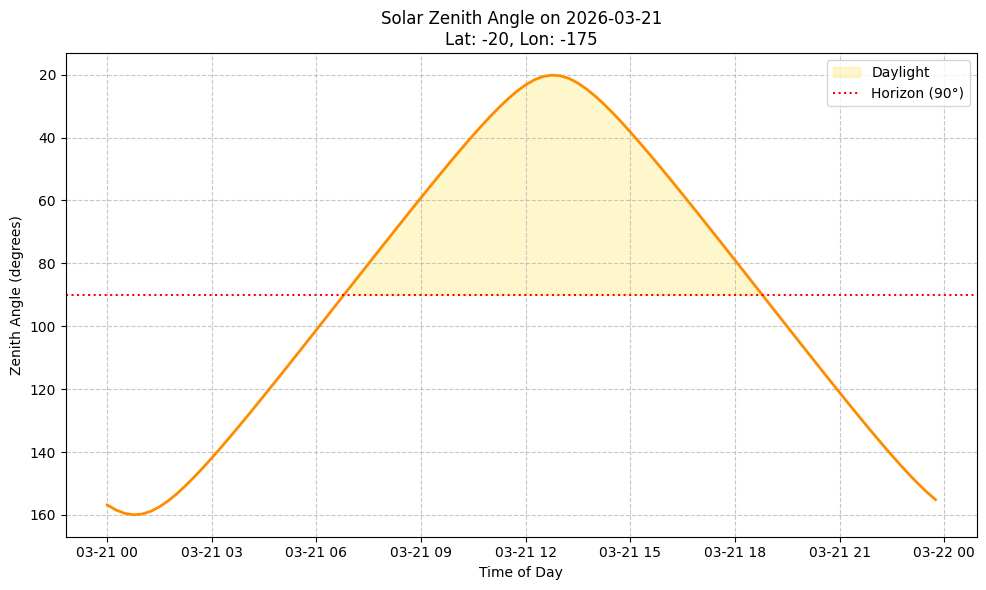

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from pvlib.solarposition import get_solarposition

def plot_solar_zenith(lat, lon, date_str, tz='UTC'):
    # 1. Define the time range for a single day
    times = pd.date_range(start=date_str, periods=24*4, freq='15min', tz=tz)
    
    # 2. Calculate solar position
    # This returns a DataFrame with azimuth, elevation, zenith, etc.
    solpos = get_solarposition(times, lat, lon)
    
    # 3. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(times, solpos['zenith'], color='darkorange', linewidth=2)
    
    # Formatting the chart
    plt.gca().invert_yaxis()  # Zenith is 0° at the top (overhead)
    plt.title(f'Solar Zenith Angle on {date_str}\nLat: {lat}, Lon: {lon}')
    plt.xlabel('Time of Day')
    plt.ylabel('Zenith Angle (degrees)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.fill_between(times, solpos['zenith'], 90, where=(solpos['zenith'] <= 90), 
                     color='gold', alpha=0.2, label='Daylight')
    
    plt.axhline(90, color='red', linestyle=':', label='Horizon (90°)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example Usage:
plot_solar_zenith(lat=-20, lon=-175, date_str='2026-03-21', tz='UTC+13:00')

## GPS Plotting
(I have some animated map code somewhere...)

/tmp/ipykernel_257/155561123.py:14: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



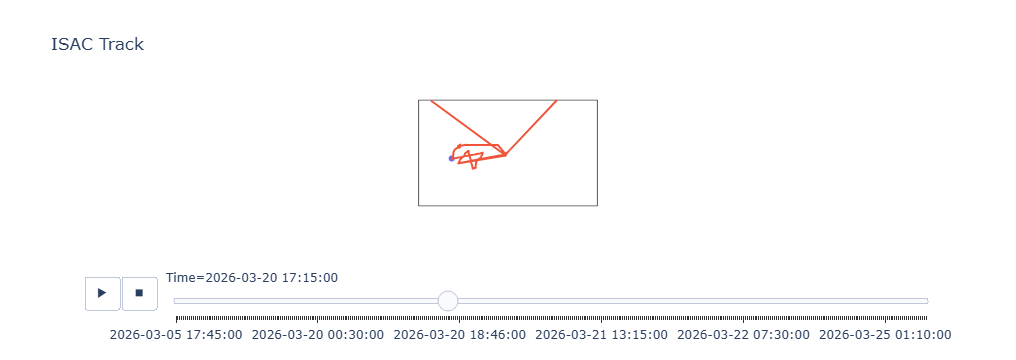

FileNotFoundError: [Errno 2] No such file or directory: 'plots/PACSUN2603.html'

In [35]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import io

# Download file:
# r2r.get_cruise_nav("RR2402")

# Read the CSV data directly from the file.
# The 'comment='#' will automatically skip lines starting with '#'.
df = pd.read_csv("ISAC_PACSUN2603.csv", comment='#')

# Convert 'iso_time' column to datetime objects
df['time'] = pd.to_datetime(df['DeviceDateTime'])

# Sort the DataFrame by time to ensure correct animation order
df = df.sort_values(by='time')

# Add a 'trace_id' column for the animation_group.
# By making this a constant, Plotly Express will draw the entire trace
# up to the current animation frame, creating a persistent trail.
df['trace_id'] = 'AgeInSeconds'

df = df.sort_values('Datetime') # sort to avoid plotting errors

# Create the animated geoscatter plot using plotly express
# 'lon' for longitude, 'lat' for latitude
# 'animation_frame' is set to 'iso_time' to create the animation
# 'animation_group' is set to 'trace_id' to make the line persist
# 'title' provides a descriptive title for the plot
# 'height' sets the height of the plot
# 'size_max' adjusts the marker size for the current point
# 'projection' sets the map projection type

fig = px.scatter_geo(df,
                     lon="Longitude",
                     lat="Latitude",
                    #  color="speed_made_good",
                     animation_frame="time",
                     animation_group="trace_id", # This makes the line persist
                     title="ISAC Track",
                     height=600,
                     size_max=500,
                     projection="natural earth", # Or "orthographic", "mercator", "winkel3", etc.
                     labels={"Longitude": "Longitude", "Latitude": "Latitude", "time": "Time"}
                    )
# Create line trace
line_trace = go.Scattergeo(lat=df['Latitude'], lon=df['Longitude'], mode='lines', name='line')
# Add line trace to the figure
fig.add_trace(line_trace)
fig.update_traces(line=dict(width=2)) # Set the line width to 2 (adjust as needed)


# ---
## Centering the Map
# ---

# Update the geographic scope to center the map over Southern California
fig.update_geos(
    center=dict(lat=-21, lon=-175),  # Approximate center of Southern California
    lataxis_range=[-20, -22],  # Latitude range for Southern California
    lonaxis_range=[-172, -176], # Longitude range for Southern California
    landcolor="rgb(243, 243, 243)",
    countrycolor="rgb(204, 204, 204)"
)

# ---
## Adjusting Animation Speed
# ---

# Update layout for better aesthetics, including adjusting the animation speed
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 500  # Adjust animation speed in milliseconds
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 200 # Adjust transition duration

# Show the plot
fig.update_layout(showlegend=False)
fig.show()
fig.write_html('PACSUN2603.html')


In [30]:
df = pd.read_csv("ISAC_PACSUN2603.csv", comment='#')
df.head()

,DataId,CommId,DeviceName,DeviceDateTime,AgeInSeconds,BatteryVoltage,GpsQuality,Latitude,Longitude,SubmergedBoolean,Temperature0cm,Unnamed: 11,station
0,66151080,3.010000e+14,USC/MTEL-UT-0001,3/25/26 4:20,15615,10.5,3,-21.138689,-175.182998,0,NaN,NaN,1
1,66151044,3.010000e+14,USC/MTEL-UT-0001,3/25/26 4:10,15011,10.5,3,-21.122586,-175.178593,0,NaN,NaN,2
2,66151003,3.010000e+14,USC/MTEL-UT-0001,3/25/26 4:00,14410,10.5,3,-21.103311,-175.171562,0,NaN,NaN,3
3,66150858,3.010000e+14,USC/MTEL-UT-0001,3/25/26 3:50,13808,10.5,3,-21.103620,-175.171235,0,NaN,NaN,4
4,66150839,3.010000e+14,USC/MTEL-UT-0001,3/25/26 3:40,13208,10.5,3,-21.103636,-175.170457,0,NaN,NaN,5
